In [1]:
#!/usr/bin/env python3 

In [8]:
# Importing the necessary modules 
import os 
import cv2 
import random 
import joblib
import numpy as np 
import seaborn as sns
from tqdm import tqdm 
import tensorflow as tf 
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder  
from tensorflow.keras.utils import to_categorical 
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, backend as K
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

<h2> Fingerprint Data Processing Module </h2>

In [9]:
class FingerprintDataProcessor: 
    def __init__(self, dataDir, imgSize=(160, 160)): 
        self.dataDir = dataDir
        self.imgSize = imgSize 
        self.labelEncoder = LabelEncoder() 

    def loadAndPreprocessImage(self, imagePath): 
        img = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE) 
        if img is None: 
            return None 
        img = cv2.resize(img, self.imgSize)
        img = img.astype("float32") / 255.0 
        img = np.expand_dims(img, axis=-1) 
        return img 

    def loadDataset(self): 
        images = []
        labels = []

        for labelName in os.listdir(self.dataDir): 
            if (labelName == ".DS_Store") or (labelName.startswith(".")):
                continue
                
            labelDir = os.path.join(self.dataDir, labelName)
            if not os.path.isdir(labelDir): 
                continue 

            print(f"Loading {labelName} fingerprints...") 
            for imageFile in tqdm(os.listdir(labelDir)): 
                if imageFile.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")): 
                    imgPath = os.path.join(labelDir, imageFile)
                    img = self.loadAndPreprocessImage(imgPath) 
                    if img is not None: 
                        images.append(img)
                        labels.append(labelName) 

        # Fit label encoder
        self.labelEncoder.fit(labels)
        
        return np.array(images), np.array(labels) 

    def createTriplets(self, images, labels): 
        """Create triplets for training"""
        triplets = [] 
        labelToIndices = {} 

        for idx, label in enumerate(labels): 
            if label not in labelToIndices: 
                labelToIndices[label] = []
            labelToIndices[label].append(idx) 

        # For each anchor
        for anchorIdx, anchorLabel in enumerate(labels): 
            # Get positive indices (same label, different image)
            positiveIndices = [idx for idx in labelToIndices[anchorLabel] if idx != anchorIdx]
            if len(positiveIndices) == 0: 
                continue 

            positiveIdx = np.random.choice(positiveIndices) 
            
            # Get negative indices (different label)
            negativeLabels = [l for l in labelToIndices.keys() if l != anchorLabel] 
            if len(negativeLabels) == 0: 
                continue 

            negativeLabel = np.random.choice(negativeLabels) 
            negativeIdx = np.random.choice(labelToIndices[negativeLabel]) 

            triplets.append((anchorIdx, positiveIdx, negativeIdx)) 

        return np.array(triplets) 

    def generateBatches(self, images, triplets, batchSize=32): 
        """Generate batches of triplets"""
        numTriplets = len(triplets) 
        if numTriplets == 0:
            return
        
        indices = np.random.permutation(numTriplets) 

        for start in range(0, numTriplets, batchSize): 
            end = min(start + batchSize, numTriplets) 
            batchIndices = indices[start:end]

            batchAnchors = [] 
            batchPositives = [] 
            batchNegatives = [] 

            for idx in batchIndices: 
                anchorIdx, positiveIdx, negativeIdx = triplets[idx]
                batchAnchors.append(images[anchorIdx]) 
                batchPositives.append(images[positiveIdx]) 
                batchNegatives.append(images[negativeIdx]) 

            # Convert to numpy arrays
            anchors = np.array(batchAnchors, dtype=np.float32)
            positives = np.array(batchPositives, dtype=np.float32)
            negatives = np.array(batchNegatives, dtype=np.float32)
            
            # For triplet loss, y_true is dummy (not used)
            dummy_labels = np.zeros((len(batchIndices),))
            
            yield (anchors, positives, negatives), dummy_labels

<h2> Siamese Network Model </h2>

In [27]:
class SiameseNetwork: 
    def __init__(self, inputShape=(160, 160, 1), embeddingDim=128): 
        self.inputShape = inputShape 
        self.embeddingDim = embeddingDim 
        self.embeddingModel = self.buildEmbeddingModel() 

    def buildEmbeddingModel(self):
        """Build embedding model with proper architecture"""
        inputLayer = layers.Input(shape=self.inputShape, name="embeddingInput")
        
        # Convert grayscale to 3 channels for MobileNetV2 if needed
        if self.inputShape[-1] == 1:
            x = layers.Conv2D(3, (3, 3), padding='same', name='grayscale_to_rgb')(inputLayer)
        else:
            x = inputLayer
        
        # Use pretrained MobileNetV2 as backbone
        baseModel = MobileNetV2(
            input_shape=(self.inputShape[0], self.inputShape[1], 3),
            include_top=False,
            weights='imagenet'  # Use pretrained weights
        )
        
        # Freeze base model initially
        baseModel.trainable = False
        
        x = baseModel(x)
        x = layers.GlobalAveragePooling2D()(x)
        
        # Dense layers for embedding
        x = layers.Dense(512, activation='relu', name="dense1")(x)
        x = layers.BatchNormalization(name="bn1")(x)
        x = layers.Dropout(0.3, name="dropout1")(x)
        
        x = layers.Dense(256, activation='relu', name="dense2")(x)
        x = layers.BatchNormalization(name="bn2")(x)
        x = layers.Dropout(0.2, name="dropout2")(x)
        
        # Embedding layer
        x = layers.Dense(self.embeddingDim, name="embeddings")(x)
        
        # L2 Normalization
        # embeddings = layers.Lambda(
        #     lambda t: tf.math.l2_normalize(t, axis=1),
        #     name="normalizedEmbeddings"
        # )(x)
        embeddings = layers.UnitNormalization(axis=1, name="normalizedEmbeddings")(x)
        
        embeddingModel = models.Model(inputs=inputLayer, outputs=embeddings, name="embeddingModel")
        return embeddingModel

    def tripletLoss(self, margin=1.0):
        """Fixed triplet loss function"""
        def loss(y_true, y_pred):
            # Split the concatenated embeddings
            anchor, positive, negative = tf.split(y_pred, 3, axis=1)
            
            # Calculate Euclidean distances
            pos_distance = tf.reduce_sum(tf.square(anchor - positive), axis=1)
            neg_distance = tf.reduce_sum(tf.square(anchor - negative), axis=1)
            
            # Triplet loss
            basic_loss = pos_distance - neg_distance + margin
            loss_value = tf.reduce_mean(tf.maximum(basic_loss, 0.0))
            
            return loss_value
        return loss

    def tripletAccuracy(self, y_true, y_pred):
        """Calculate triplet accuracy"""
        anchor, positive, negative = tf.split(y_pred, 3, axis=1)
        
        pos_distance = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_distance = tf.reduce_sum(tf.square(anchor - negative), axis=1)
        
        # Accurate if positive is closer than negative
        return tf.reduce_mean(tf.cast(pos_distance < neg_distance, tf.float32))

    def buildSiameseModel(self):
        """Build complete Siamese model"""
        anchorInput = layers.Input(shape=self.inputShape, name="anchorInput")
        positiveInput = layers.Input(shape=self.inputShape, name="positiveInput")
        negativeInput = layers.Input(shape=self.inputShape, name="negativeInput")
        
        anchorEmbedding = self.embeddingModel(anchorInput)
        positiveEmbedding = self.embeddingModel(positiveInput)
        negativeEmbedding = self.embeddingModel(negativeInput)
        
        mergedOutputs = layers.concatenate(
            [anchorEmbedding, positiveEmbedding, negativeEmbedding], 
            axis=1, 
            name="mergedEmbeddings"
        )
        
        siameseModel = models.Model(
            inputs=[anchorInput, positiveInput, negativeInput], 
            outputs=mergedOutputs, 
            name="siameseNetwork"
        )
        return siameseModel

    def compileModel(self, learningRate=0.0001):
        """Compile the Siamese model"""
        model = self.buildSiameseModel()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learningRate),
            loss=self.tripletLoss(margin=1.0),
            metrics=[self.tripletAccuracy]
        )
        return model

<h2> Fingerprint Recognizer </h2>

In [28]:
class FingerprintRecognizer: 
    def __init__(self, embeddingModel, labelEncoder, threshold=0.5): 
        self.embeddingModel = embeddingModel
        self.labelEncoder = labelEncoder 
        self.threshold = threshold 
        self.referenceEmbeddings = {} 

    def generateEmbedding(self, image):
        """Generate embedding for a single image"""
        if len(image.shape) == 3: 
            image = np.expand_dims(image, axis=0) 
        embedding = self.embeddingModel.predict(image, verbose=0) 
        return embedding[0]

    def registerFingerprint(self, image, label): 
        """Register a fingerprint with its label"""
        embedding = self.generateEmbedding(image) 
        if label not in self.referenceEmbeddings: 
            self.referenceEmbeddings[label] = []
        self.referenceEmbeddings[label].append(embedding) 

    def computeSimilarity(self, embedding1, embedding2): 
        """Compute cosine similarity"""
        embedding1 = embedding1 / (np.linalg.norm(embedding1) + 1e-8)
        embedding2 = embedding2 / (np.linalg.norm(embedding2) + 1e-8)
        similarity = np.dot(embedding1, embedding2) 
        return similarity 

    def predict(self, image): 
        """Predict the label for a fingerprint image"""
        queryEmbedding = self.generateEmbedding(image) 
        bestMatch = None 
        bestSimilarity = -1 

        for label, embeddings in self.referenceEmbeddings.items(): 
            similarities = [self.computeSimilarity(queryEmbedding, refEmb) 
                            for refEmb in embeddings]
            maxSimilarity = max(similarities) if similarities else -1 
            if maxSimilarity > bestSimilarity: 
                bestSimilarity = maxSimilarity
                bestMatch = label 

        if bestSimilarity > self.threshold: 
            return bestMatch, bestSimilarity 
        else: 
            return "unknown", bestSimilarity

<h2> Training Pipeline </h2>

In [29]:
class TrainingPipeline: 
    def __init__(self, dataProcessor, siameseNetwork): 
        self.dataProcessor = dataProcessor 
        self.siameseNetwork = siameseNetwork 

    def train(self, epochs=50, batchSize=32, validationSplit=0.2): 
        print("[INFO]: Loading the dataset...")
        images, labels = self.dataProcessor.loadDataset() 
        print(f"[INFO]: Loaded {len(images)} images with {len(np.unique(labels))} classes") 

        # Split data
        trainIdx, valIdx = train_test_split(
            range(len(images)), 
            test_size=validationSplit, 
            stratify=labels, 
            random_state=42 
        )

        trainImages = images[trainIdx] 
        trainLabels = labels[trainIdx] 
        valImages = images[valIdx] 
        valLabels = labels[valIdx] 

        print(f"Training samples: {len(trainImages)}")
        print(f"Validation samples: {len(valImages)}") 

        # Create triplets
        print("[INFO]: Creating training triplets...") 
        trainTriplets = self.dataProcessor.createTriplets(trainImages, trainLabels) 
        print(f"[INFO]: Created {len(trainTriplets)} training triplets") 
        
        print("[INFO]: Creating validation triplets...") 
        valTriplets = self.dataProcessor.createTriplets(valImages, valLabels) 
        print(f"[INFO]: Created {len(valTriplets)} validation triplets") 

        # Check if triplets exist
        if len(trainTriplets) == 0:
            raise ValueError("No triplets created! Check your dataset.")
        
        # Compile model
        model = self.siameseNetwork.compileModel(learningRate=0.001)  # Higher initial LR

        # Callbacks
        callbacks = [
            ModelCheckpoint(
                "models/bestSiameseModel.h5", 
                save_best_only=True, 
                monitor="val_loss", 
                mode="min",
                verbose=1
            ), 
            EarlyStopping(
                monitor="val_loss", 
                patience=20,  # Increased patience
                restore_best_weights=True,
                verbose=1
            ), 
            ReduceLROnPlateau(
                monitor="val_loss", 
                factor=0.5, 
                patience=8,  # Increased patience
                min_lr=1e-7,
                verbose=1
            )
        ]

        # Create tf.data datasets
        def train_generator():
            for batch in self.dataProcessor.generateBatches(trainImages, trainTriplets, batchSize):
                yield batch
        
        def val_generator():
            for batch in self.dataProcessor.generateBatches(valImages, valTriplets, batchSize):
                yield batch

        # Define output signature
        img_spec = tf.TensorSpec(shape=(None, 160, 160, 1), dtype=tf.float32)
        dataset_signature = (
            (img_spec, img_spec, img_spec),
            tf.TensorSpec(shape=(None,), dtype=tf.float32)
        )

        train_dataset = tf.data.Dataset.from_generator(
            train_generator,
            output_signature=dataset_signature
        )
        
        val_dataset = tf.data.Dataset.from_generator(
            val_generator,
            output_signature=dataset_signature
        )
        
        train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
        val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

        steps_per_epoch = max(1, len(trainTriplets) // batchSize)
        validation_steps = max(1, len(valTriplets) // batchSize)
        
        print(f"Steps per epoch: {steps_per_epoch}")
        print(f"Validation steps: {validation_steps}")
        print("[INFO]: Starting the training session...") 
        
        history = model.fit(
            train_dataset,
            steps_per_epoch=steps_per_epoch, 
            validation_data=val_dataset,
            validation_steps=validation_steps,
            epochs=epochs, 
            callbacks=callbacks, 
            verbose=1
        )

        return model, history 

    def saveModel(self, model, recognizer, modelPath="models/", recognizerPath="models/"): 
        os.makedirs(modelPath, exist_ok=True) 
        os.makedirs(recognizerPath, exist_ok=True)
        
        # Save the embedding model (not the Siamese model)
        recognizer.embeddingModel.save(os.path.join(modelPath, 'embeddingModel.h5')) 
        joblib.dump(recognizer, os.path.join(recognizerPath, 'fingerprintRecognizer.pkl')) 
        joblib.dump(self.dataProcessor.labelEncoder, 
                    os.path.join(recognizerPath, 'labelEncoder.pkl')) 
        print("[INFO]: Models saved successfully!")

    def registerFingerprintsForRecognizer(self, recognizer, images, labels, samplesPerClass=10):
        uniqueLabels = np.unique(labels) 
        for label in uniqueLabels: 
            labelIndices = np.where(labels == label)[0]
            registerIndices = labelIndices[:min(samplesPerClass, len(labelIndices))] 
            for idx in registerIndices:
                recognizer.registerFingerprint(images[idx], label) 
            print(f"Registered {len(registerIndices)} fingerprints for {label}") 
        return recognizer

<h2> Utilities Section </h2>

In [30]:
def preprocessImageForInference(imagePath, imageSize=(160, 160)): 
    img = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE) 
    if img is None: 
        print(f"[INFO]: Error loading the image: {imagePath}") 
        return None 
    img = cv2.resize(img, imageSize) 
    img = img.astype('float32') / 255.0 
    img = np.expand_dims(img, axis=-1) 
    return img 

def visualizeEmbeddings(embeddings, labels, title="Fingerprint Embeddings Visualization"): 
    if len(embeddings) < 2:
        print("Not enough embeddings for visualization")
        return
    
    pca = PCA(n_components=2) 
    embeddings2D = pca.fit_transform(embeddings) 
    plt.figure(figsize=(12, 8)) 
    uniqueLabels = np.unique(labels) 
    colors = plt.cm.rainbow(np.linspace(0, 1, len(uniqueLabels)))
    for label, color in zip(uniqueLabels, colors): 
        mask = labels == label
        plt.scatter(embeddings2D[mask, 0], embeddings2D[mask, 1], 
                    c=[color], label=label, alpha=0.7)
    plt.title(title) 
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2") 
    plt.legend() 
    plt.grid(True, alpha=.3)
    plt.show() 

def evaluateModel(recognizer, testImages, testLabels, threshold=.5): 
    predictions = [] 
    confidences = [] 
    for img, trueLabel in zip(testImages, testLabels): 
        predLabel, confidence = recognizer.predict(img) 
        predictions.append(predLabel)
        confidences.append(confidence) 
    
    print("\nClassification Report: ")
    print(classification_report(testLabels, predictions))
    
    # Get all unique labels for confusion matrix
    all_labels = list(set(testLabels) | set(predictions))
    cm = confusion_matrix(testLabels, predictions, labels=all_labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=all_labels, yticklabels=all_labels)
    plt.title("Confusion Matrix") 
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label") 
    plt.show() 
    return predictions, confidences

def plotTrainingPerformance(history):
    """Plot training and validation metrics"""
    if not history or not history.history:
        print("No training history available")
        return
    
    trainLoss = history.history.get('loss', [])
    valLoss = history.history.get('val_loss', [])
    
    if not trainLoss:
        print("No loss data in history")
        return
    
    epochsRange = range(1, len(trainLoss) + 1)
    plt.figure(figsize=(16, 6))
    
    # Loss curves
    plt.subplot(1, 2, 1)
    plt.plot(epochsRange, trainLoss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochsRange, valLoss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Triplet Loss History', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Accuracy curves
    plt.subplot(1, 2, 2)
    if 'tripletAccuracy' in history.history:
        trainAcc = history.history['tripletAccuracy']
        valAcc = history.history.get('val_tripletAccuracy', [])
        plt.plot(epochsRange, trainAcc, 'b-', label='Training Accuracy', linewidth=2)
        if valAcc:
            plt.plot(epochsRange, valAcc, 'r-', label='Validation Accuracy', linewidth=2)
        plt.title('Triplet Accuracy History', fontsize=12, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy Score')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

<h2> Inference Module </h2>

In [31]:
class FingerprintInference: 
    def __init__(self, modelPath, recognizerPath): 
        self.model = tf.keras.models.load_model(
            modelPath, 
            safe_mode=False,
            custom_objects={
                "loss": lambda y_true, y_pred: y_pred,
                "tripletLoss": lambda margin: lambda y_true, y_pred: y_pred,
                "tripletAccuracy": lambda y_true, y_pred: y_pred
            }
        )
        self.recognizer = joblib.load(recognizerPath) 
        self.recognizer.embeddingModel = self.model 

    def predictSingleImage(self, imagePath): 
        image = preprocessImageForInference(imagePath) 
        if image is None: 
            return None, 0.0
        label, confidence = self.recognizer.predict(image) 
        return label, confidence 

    def predictBatch(self, imagePaths): 
        results = [] 
        for path in imagePaths: 
            label, confidence = self.predictSingleImage(path) 
            results.append({
                "imagePath": path, 
                "predictedLabel": label, 
                "confidence": float(confidence)
            })
        return results 

    def registerNewFingerprint(self, imagePath, label): 
        image = preprocessImageForInference(imagePath) 
        if image is None: 
            return False 
        self.recognizer.registerFingerprint(image, label) 
        joblib.dump(self.recognizer, 'models/fingerprintRecognizerUpdated.pkl') 
        return True


<h2> Training the model </h2>

In [32]:
# Setting the necessary configurations 
dataDir = "dataset" 
modelDir = "models" 
imgSize = (160, 160)
embeddingDim = 128 
epochs = 10
batchSize = 16

os.makedirs(modelDir, exist_ok=True) 

print("="*50)
print("STEP 1: Loading and preprocessing data")
print("="*50)

dataProcessor = FingerprintDataProcessor(dataDir, imgSize) 
images, labels = dataProcessor.loadDataset()

STEP 1: Loading and preprocessing data
Loading mike fingerprints...


100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 767.19it/s]


Loading adams fingerprints...


100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 859.59it/s]


Loading unknown fingerprints...


100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 518.51it/s]


Loading kim fingerprints...


100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 889.73it/s]


Loading sarah fingerprints...


100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 921.35it/s]


In [33]:
print("\n" + "="*50)
print("STEP 2: Building Siamese network")
print("="*50)

siameseNetwork = SiameseNetwork(
    inputShape=(imgSize[0], imgSize[1], 1), 
    embeddingDim=embeddingDim
)


STEP 2: Building Siamese network


In [34]:
# Train the model 
print("\n" + "=" * 50)
print("[INFO] Training the model...")
print("=" * 50)
pipeline = TrainingPipeline(dataProcessor, siameseNetwork) 
model, history = pipeline.train(epochs=epochs, batchSize=batchSize)


[INFO] Training the model...
[INFO]: Loading the dataset...
Loading mike fingerprints...


100%|█████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1121.35it/s]


Loading adams fingerprints...


100%|█████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1428.72it/s]


Loading unknown fingerprints...


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 443ms/step - loss: 0.1253 - triplet_accuracy: 0.9625 - val_loss: 0.0391 - val_triplet_accuracy: 0.9896 - learning_rate: 0.0010
Epoch 4/10

Epoch 4: val_loss did not improve from 0.03915
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0000e+00 - triplet_accuracy: 0.0000e+00 - val_loss: 0.0396 - val_triplet_accuracy: 0.9896 - learning_rate: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - loss: 0.0514 - triplet_accuracy: 0.9809
Epoch 5: val_loss improved from 0.03915 to 0.02035, saving model to models/bestSiameseModel.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 489ms/step - loss: 0.0466 - triplet_accuracy: 0.9862 - val_loss: 0.0204 - val_triplet_accuracy: 0.9948 - learning_rate: 0.0010
Epoch 6/10


2026-05-17 02:54:04.087116: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Epoch 6: val_loss did not improve from 0.02035
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0000e+00 - triplet_accuracy: 0.0000e+00 - val_loss: 0.0229 - val_triplet_accuracy: 0.9948 - learning_rate: 0.0010
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 0.0395 - triplet_accuracy: 0.9955
Epoch 7: val_loss improved from 0.02035 to 0.01396, saving model to models/bestSiameseModel.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step - loss: 0.0310 - triplet_accuracy: 0.9950 - val_loss: 0.0140 - val_triplet_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 8/10

Epoch 8: val_loss did not improve from 0.01396
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0000e+00 - triplet_accuracy: 0.0000e+00 - val_loss: 0.0140 - val_triplet_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - loss: 0.0196 - triplet_accuracy: 0.9952
Epoch 9: val_loss did not improve from 0.01396
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 476ms/step - loss: 0.0211 - triplet_accuracy: 0.9962 - val_loss: 0.0141 - val_triplet_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 10/10

Epoch 10: val_loss did not improve from 0.01396
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0000e+00 - triplet_accuracy: 0.0000e+00 - val_loss: 0.0141 - val_triplet_accuracy: 1.0000 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.


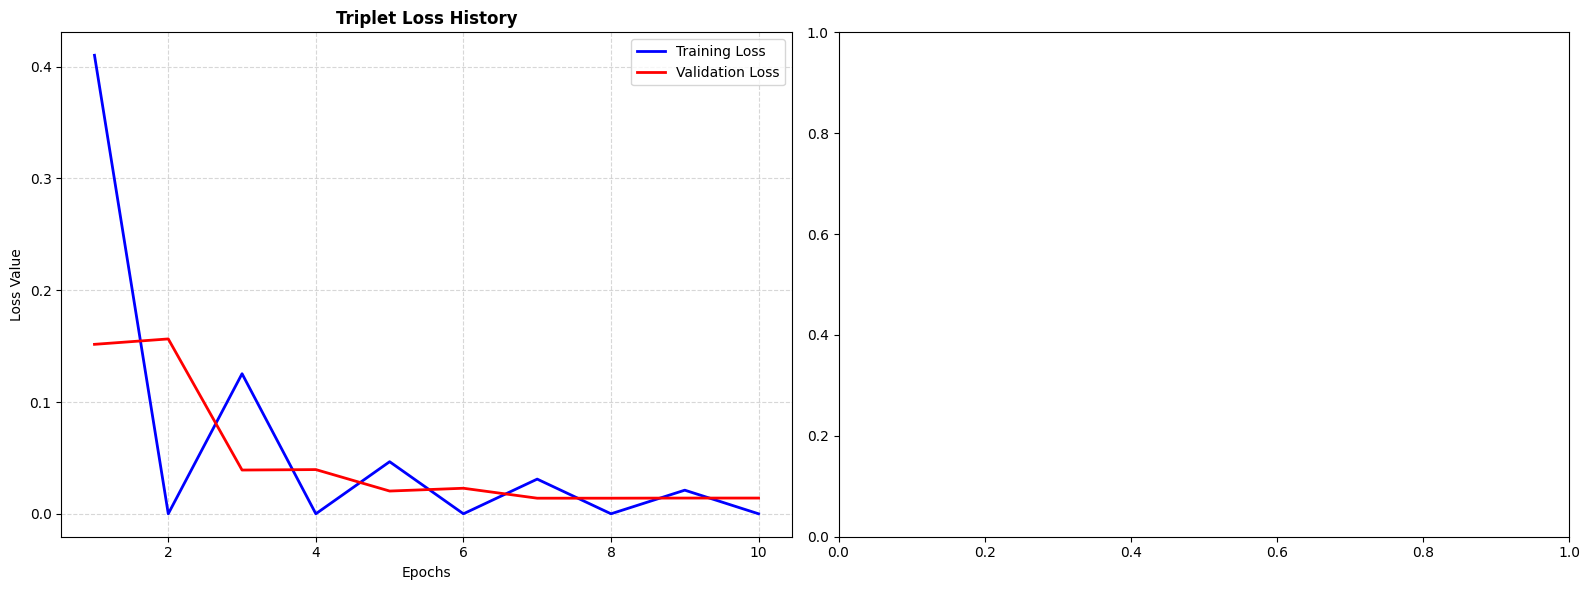

In [35]:
# Plot training performance
plotTrainingPerformance(history)

In [36]:
# Create and register fingerprints for recognizer 
print("\n" + "="*50)
print("STEP 4: Creating fingerprint recognizer")
print("="*50)
recognizer = FingerprintRecognizer(
    embeddingModel=siameseNetwork.embeddingModel, 
    labelEncoder=dataProcessor.labelEncoder, 
    threshold=.6
)

# Register fingerprints (using first 10 samples per class) 
pipeline.registerFingerprintsForRecognizer(
    recognizer, images, labels, samplesPerClass=10
)


STEP 4: Creating fingerprint recognizer
Registered 10 fingerprints for adams
Registered 10 fingerprints for kim
Registered 10 fingerprints for mike
Registered 10 fingerprints for sarah
Registered 10 fingerprints for unknown


In [37]:
# Save model and recognizer 
print("\n" + "="*50)
print("STEP 5: Saving models")
print("="*50)
pipeline.saveModel(model, recognizer) 


STEP 5: Saving models
[INFO]: Models saved successfully!


In [38]:
def plotTrainingPerformance(history):
    """
    Plots the training and validation triplet loss and triplet accuracy using camelCase variables.
    """
    trainLoss = history.history['loss']
    valLoss = history.history['val_loss']
    epochsRange = range(1, len(trainLoss) + 1)

    plt.figure(figsize=(16, 6))

    # Subplot 1: Loss curves
    plt.subplot(1, 2, 1)
    plt.plot(epochsRange, trainLoss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochsRange, valLoss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Triplet Loss History', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Subplot 2: Accuracy curves
    plt.subplot(1, 2, 2)
    
    # Check if the camelCase accuracy metric exists in the logs
    accuracyKey = 'tripletAccuracy' if 'tripletAccuracy' in history.history else 'accuracy'
    validationAccuracyKey = f'val_{accuracyKey}'
    
    if accuracyKey in history.history:
        plt.plot(epochsRange, history.history[accuracyKey], 'b-', label='Training Accuracy', linewidth=2)
        plt.plot(epochsRange, history.history[validationAccuracyKey], 'r-', label='Validation Accuracy', linewidth=2)
        plt.title('Triplet Accuracy History', fontsize=12, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy Score')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        plt.text(0.5, 0.5, 'Accuracy key not tracked.\nEnsure compileModel() runs with metrics=[self.tripletAccuracy]', 
                 horizontalalignment='center', verticalalignment='center', fontsize=11, color='gray')
        plt.title('Triplet Accuracy History', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

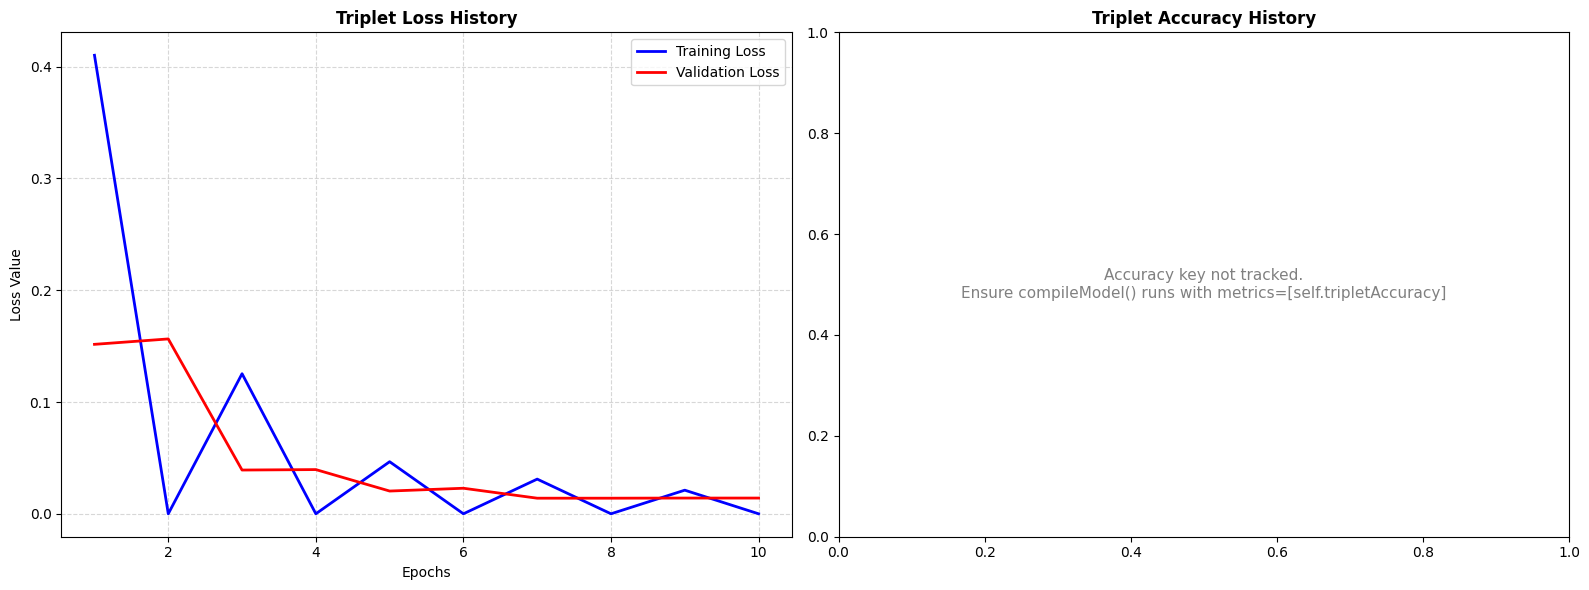

In [39]:
plotTrainingPerformance(history)

<h2> Test Inference System </h2>

In [40]:
# Load inference system 
inferenceSystem = FingerprintInference(
    modelPath=os.path.join(modelDir, 'embeddingModel.h5'), 
    recognizerPath=os.path.join(modelDir, 'fingerprintRecognizer.pkl')
)

# Test with sample images 
samplePredictions = {} 

# looping 
for label in np.unique(labels): 
    labelIndicies = np.where(labels == label)[0] 

    # 
    if len(labelIndicies) > 10: 
        testIdx = labelIndicies[10]
        testImage = images[testIdx]

        # 
        predLabel, confidence = recognizer.predict(testImage) 
        samplePredictions[label] = (predLabel, confidence) 

        # 
        print(f"True: {label} -> Predicted: {predLabel} (confidence: {confidence:.3f})")

True: adams -> Predicted: adams (confidence: 0.943)
True: kim -> Predicted: kim (confidence: 0.986)
True: mike -> Predicted: mike (confidence: 0.989)
True: sarah -> Predicted: sarah (confidence: 0.911)
True: unknown -> Predicted: unknown (confidence: 0.980)


<h2> Second Testing </h2>

In [47]:
# Getting the path to an image 
imagePath = "dataset/mike/aug_104_1_1_left_real_ZK9500.jpg"

# 
img = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE) 

#
img = cv2.resize(img, imgSize)
img = img.astype("float32") / 255.0 
img = np.expand_dims(img, axis=-1) 


# Making some predictions 
predLabel, confidence = recognizer.predict(img) 

In [48]:
print(predLabel)

mike


In [49]:
print(f"{confidence * 100:.3f}%")

98.986%
